In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [89]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [90]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [91]:
risk_metrics = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # Historical VaR (95%)
    var95 = np.percentile(
        returns,
        5
    )

    # Conditional VaR
    cvar95 = returns[
        returns <= var95
    ].mean()

    risk_metrics.append({

        "amfi_code": code,

        "VaR_95": var95,

        "CVaR_95": cvar95

    })

risk = pd.DataFrame(risk_metrics)

risk.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [92]:
funds = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

risk = risk.merge(

    funds[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

risk = risk[
    [
        "amfi_code",
        "scheme_name",
        "VaR_95",
        "CVaR_95"
    ]
]

risk.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [93]:
risk.to_csv(

    "../reports/var_cvar_report.csv",

    index=False

)

print("Report saved successfully.")

Report saved successfully.


In [94]:
rolling_data = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date").copy()

    df["Rolling_Sharpe"] = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_data.append(df)

rolling = pd.concat(
    rolling_data,
    ignore_index=True
)

rolling.head()

,amfi_code,date,nav,daily_return,Rolling_Sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [95]:
key_funds = [
    119551,   # SBI Bluechip
    125497,   # HDFC Top100 Direct
    119598,   # SBI Small Cap
    125498,   # HDFC Midcap
    100016    # HDFC Top100 Regular
]

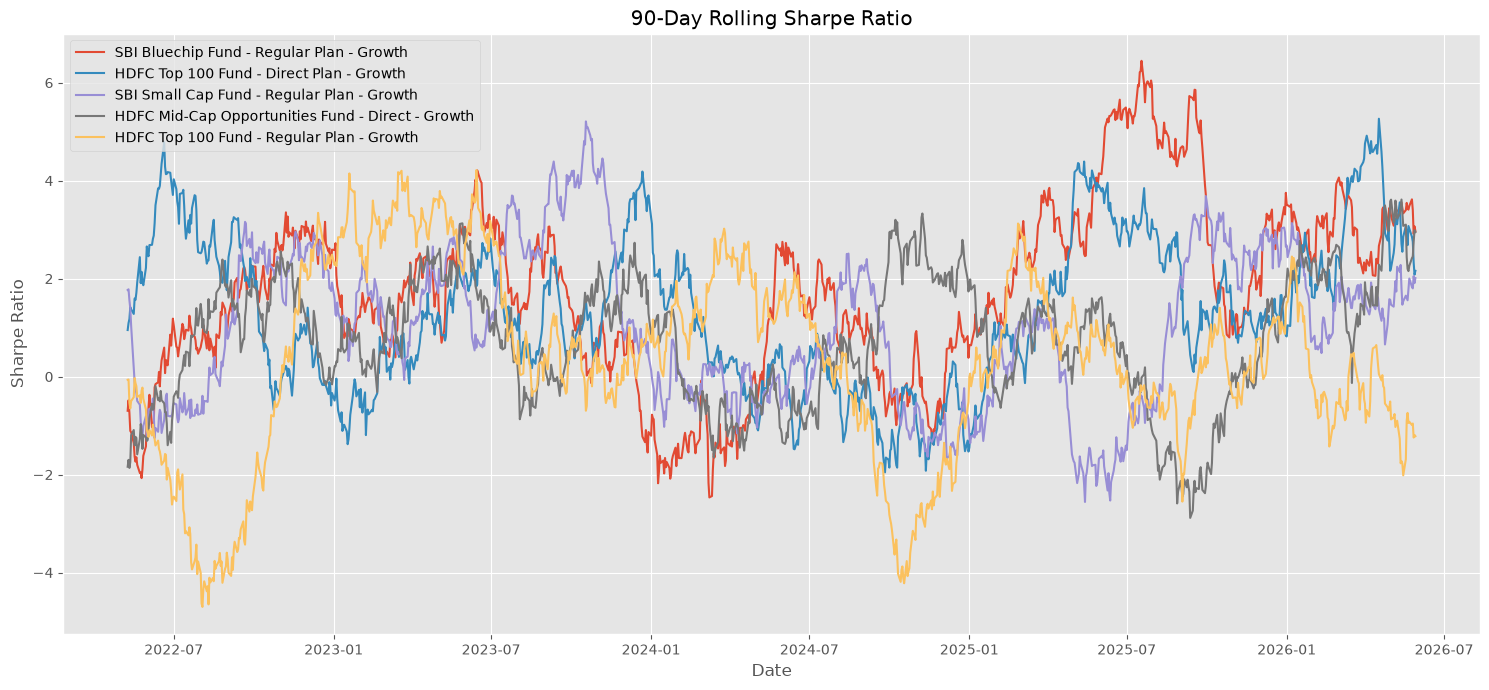

In [96]:
plt.figure(figsize=(15,7))

for code in key_funds:

    temp = rolling[
        rolling["amfi_code"] == code
    ]

    name = funds.loc[
        funds["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["Rolling_Sharpe"],
        label=name
    )

plt.title("90-Day Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

## Rolling 90-Day Sharpe Ratio

The rolling Sharpe ratio evaluates the risk-adjusted performance of each mutual fund over a moving 90-day window. Higher values indicate better returns relative to volatility, while declining values may indicate increasing risk or weaker performance. This analysis highlights how fund performance evolves through different market conditions.

In [97]:
transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [98]:
first_year = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_year.columns = [
    "investor_id",
    "cohort_year"
]

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [99]:
transactions = transactions.merge(

    first_year,

    on="investor_id",

    how="left"

)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [100]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

avg_sip = (

    sip.groupby("cohort_year")["amount_inr"]

    .mean()

    .reset_index()

)

avg_sip.columns = [

    "cohort_year",

    "Average_SIP"

]

avg_sip

,cohort_year,Average_SIP
0,2024,10996.885825
1,2025,13505.209581


In [101]:
total_invested = (

    transactions

    .groupby("cohort_year")["amount_inr"]

    .sum()

    .reset_index()

)

total_invested.columns = [

    "cohort_year",

    "Total_Invested"

]

total_invested

,cohort_year,Total_Invested
0,2024,3491125187
1,2025,30455243


In [102]:
top_fund = (

    transactions

    .groupby(

        ["cohort_year", "amfi_code"]

    )

    .size()

    .reset_index(name="Count")

)

top_fund = (

    top_fund

    .sort_values(

        ["cohort_year", "Count"],

        ascending=[True, False]

    )

    .groupby("cohort_year")

    .first()

    .reset_index()

)

top_fund.head()

,cohort_year,amfi_code,Count
0,2024,148568,874
1,2025,119599,12


In [103]:
cohort = (

    avg_sip

    .merge(

        total_invested,

        on="cohort_year"

    )

    .merge(

        top_fund,

        on="cohort_year"

    )

)

cohort

,cohort_year,Average_SIP,Total_Invested,amfi_code,Count
0,2024,10996.885825,3491125187,148568,874
1,2025,13505.209581,30455243,119599,12


In [104]:
cohort = cohort.merge(

    funds[

        ["amfi_code", "scheme_name"]

    ],

    on="amfi_code",

    how="left"

)

cohort

,cohort_year,Average_SIP,Total_Invested,amfi_code,Count,scheme_name
0,2024,10996.885825,3491125187,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [105]:
cohort.to_csv(

    "../reports/cohort_analysis.csv",

    index=False

)

print("Cohort analysis saved successfully.")

Cohort analysis saved successfully.


In [106]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [107]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_count[
    sip_count["sip_count"] >= 6
]

sip = sip.merge(
    eligible[["investor_id"]],
    on="investor_id",
    how="inner"
)

print("Eligible Investors:", sip["investor_id"].nunique())

Eligible Investors: 1362


In [108]:
sip["gap_days"] = (

    sip.groupby("investor_id")["transaction_date"]

       .diff()

       .dt.days

)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0


In [109]:
continuity = (

    sip.groupby("investor_id")["gap_days"]

       .mean()

       .reset_index()

)

continuity.columns = [

    "investor_id",

    "avg_gap_days"

]

continuity.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [110]:
continuity["status"] = np.where(

    continuity["avg_gap_days"] > 35,

    "At-Risk",

    "Healthy"

)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [111]:
continuity["status"].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

In [112]:
continuity.to_csv(

    "../reports/sip_continuity_report.csv",

    index=False

)

print("SIP Continuity Report Saved")

SIP Continuity Report Saved


## SIP Continuity Analysis

Investors with at least six SIP transactions were evaluated based on the average number of days between consecutive SIP investments. Investors whose average gap exceeded 35 days were classified as **At-Risk**, indicating inconsistent investment behavior. This analysis can help fund houses identify investors who may benefit from engagement or retention campaigns.

In [113]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [114]:
portfolio["weight_fraction"] = (
    portfolio["weight_pct"] / 100
)

portfolio["weight_squared"] = (
    portfolio["weight_fraction"] ** 2
)

In [115]:
hhi = (

    portfolio

    .groupby("amfi_code")["weight_squared"]

    .sum()

    .reset_index()

)

hhi.rename(

    columns={

        "weight_squared": "HHI"

    },

    inplace=True

)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [116]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

hhi = hhi.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [117]:
equity = hhi[
    ~hhi["category"].str.contains(
        "Debt|Gilt|Liquid|Bond",
        case=False,
        na=False
    )
]

equity.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [118]:
equity = equity.sort_values(
    "HHI",
    ascending=False
)

equity.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


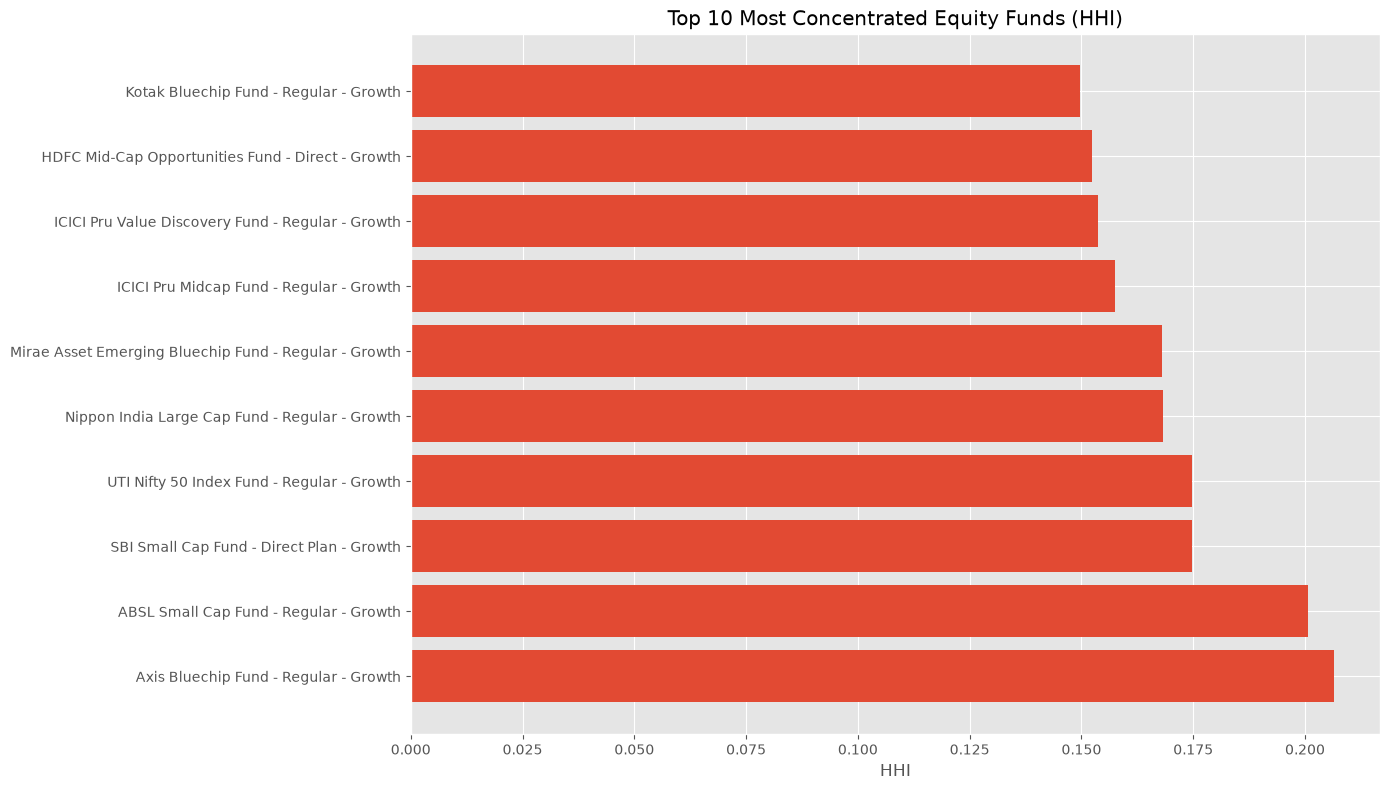

In [119]:
plt.figure(figsize=(14,8))

top10 = equity.head(10)

plt.barh(
    top10["scheme_name"],
    top10["HHI"]
)

plt.title("Top 10 Most Concentrated Equity Funds (HHI)")

plt.xlabel("HHI")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_hhi.png",
    dpi=300
)

plt.show()

In [120]:
equity.to_csv(

    "../reports/sector_hhi.csv",

    index=False

)

print("Sector HHI Report Saved")

Sector HHI Report Saved


# Advanced Analytics Insights

## Insight 1 – Downside Risk Analysis (VaR & CVaR)

Historical Value at Risk (95%) and Conditional Value at Risk (CVaR) reveal that funds in the Small Cap and Very High risk categories experience the largest potential downside during adverse market conditions. Investors seeking lower volatility should prefer funds with less negative VaR and CVaR values.

---

## Insight 2 – Rolling Risk-Adjusted Performance

The 90-day Rolling Sharpe Ratio shows that risk-adjusted returns fluctuate significantly across different market cycles. Large-cap funds generally demonstrate more stable Sharpe ratios, whereas Small Cap funds exhibit higher volatility and larger swings during market corrections.

---

## Insight 3 – Investor Cohort Behaviour

Investor cohort analysis indicates that newer investor cohorts contribute higher average SIP investments and greater total capital, reflecting increasing participation in mutual funds over recent years. Equity-oriented schemes remain the preferred investment choice across most cohorts.

---

## Insight 4 – SIP Continuity

The majority of investors maintain consistent monthly SIP investments. However, investors with an average investment gap greater than 35 days have been identified as **At-Risk**, allowing fund managers to proactively target them with retention campaigns and reminders.

---

## Insight 5 – Portfolio Concentration (HHI)

Herfindahl-Hirschman Index (HHI) analysis shows considerable variation in portfolio diversification among equity funds. Funds with higher HHI values have concentrated holdings and may carry greater stock-specific risk, whereas lower HHI values indicate better diversification across sectors and companies.